In [7]:
# pip install xgboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
import sklearn.metrics as metrics
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold

In [9]:
df = pd.read_excel(fr"processed_heart_data.xlsx")

x = df.drop('disease_present', axis=1)
y = df['disease_present']

## Initial Model Creation

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Log loss chosen because (logarithmic loss) is specifically designed for probabilistic binary classification.

In [16]:
train_start = time.perf_counter()
xgb_model1 = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model1.fit(x_train, y_train)
train_time = time.perf_counter() - train_start
print(f"Training Time: {train_time}")

Training Time: 0.0890798999753315


In [18]:
predict_start = time.perf_counter()
y_pred = xgb_model1.predict(x_test)
predict_time = time.perf_counter() - predict_start
print(f"Prediction Time: {predict_time}")

Prediction Time: 0.007466100010788068


In [20]:
print(f"Accuracy Score: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall Score: {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {metrics.f1_score(y_test, y_pred):.4f}")

Accuracy Score: 0.8361
Precision Score: 0.8929
Recall Score: 0.7812
F1 Score: 0.8333


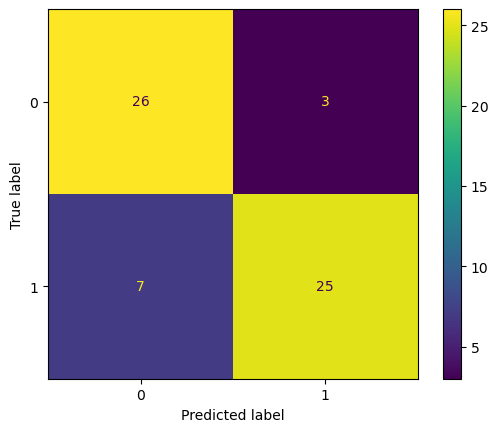

In [22]:
cm = metrics.confusion_matrix(y_test, y_pred, labels=xgb_model1.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model1.classes_)
disp.plot()

-   The upper-left quadrant displays the number of **true negatives**.
-   The bottom-left quadrant displays the number of **false negatives**.
-   The upper-right quadrant displays the number of **false positives**.
-   The bottom-right quadrant displays the number of **true positives**.

## Five Fold Cross Validation

In [27]:
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

xgb_fold_results = []
xgb_fold_times = []

In [29]:
fold_num = 1
for train_index, val_index in kf.split(x):
    # Split data
    x_train_fold, x_val_fold = x.iloc[train_index], x.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    # ===== XGBoost =====
    train_start = time.perf_counter()
    xgb_model_fold = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_model_fold.fit(x_train_fold, y_train_fold)
    train_time_xgb = time.perf_counter() - train_start
    
    predict_start = time.perf_counter()
    y_pred_xgb = xgb_model_fold.predict(x_val_fold)
    y_pred_proba_xgb = xgb_model_fold.predict_proba(x_val_fold)[:, 1]
    predict_time_xgb = time.perf_counter() - predict_start
    
    total_time_xgb = train_time_xgb + predict_time_xgb
    
    # Calculate metrics
    accuracy_xgb = accuracy_score(y_val_fold, y_pred_xgb)
    precision_xgb = precision_score(y_val_fold, y_pred_xgb, zero_division=0)
    recall_xgb = recall_score(y_val_fold, y_pred_xgb, zero_division=0)
    f1_xgb = f1_score(y_val_fold, y_pred_xgb, zero_division=0)
    roc_auc_xgb = roc_auc_score(y_val_fold, y_pred_proba_xgb)
    
    # Store results
    xgb_fold_results.append({
        'fold': fold_num,
        'accuracy': accuracy_xgb,
        'precision': precision_xgb,
        'recall': recall_xgb,
        'f1_score': f1_xgb,
        'roc_auc': roc_auc_xgb
    })
    
    xgb_fold_times.append({
        'fold': fold_num,
        'train_time': train_time_xgb,
        'predict_time': predict_time_xgb,
        'total_time': total_time_xgb
    })
    
    print(f"Fold {fold_num}:")
    print(f"  XGBoost:")
    print(f"    Training time: {train_time_xgb:.6f}s | Prediction time: {predict_time_xgb:.6f}s | Total: {total_time_xgb:.6f}s")
    print(f"    Accuracy: {accuracy_xgb:.4f} | Precision: {precision_xgb:.4f} | Recall: {recall_xgb:.4f} | F1: {f1_xgb:.4f} | AUC: {roc_auc_xgb:.4f}")
    print()
    
    fold_num += 1

Fold 1:
  XGBoost:
    Training time: 0.078566s | Prediction time: 0.015241s | Total: 0.093807s
    Accuracy: 0.8361 | Precision: 0.8929 | Recall: 0.7812 | F1: 0.8333 | AUC: 0.9149

Fold 2:
  XGBoost:
    Training time: 0.070755s | Prediction time: 0.014465s | Total: 0.085220s
    Accuracy: 0.7541 | Precision: 0.6897 | Recall: 0.7692 | F1: 0.7273 | AUC: 0.8582

Fold 3:
  XGBoost:
    Training time: 0.068535s | Prediction time: 0.014518s | Total: 0.083053s
    Accuracy: 0.8852 | Precision: 0.8276 | Recall: 0.9231 | F1: 0.8727 | AUC: 0.9473

Fold 4:
  XGBoost:
    Training time: 0.071912s | Prediction time: 0.014387s | Total: 0.086299s
    Accuracy: 0.7667 | Precision: 0.8333 | Recall: 0.6667 | F1: 0.7407 | AUC: 0.8233

Fold 5:
  XGBoost:
    Training time: 0.066871s | Prediction time: 0.014315s | Total: 0.081187s
    Accuracy: 0.8500 | Precision: 0.8333 | Recall: 0.8000 | F1: 0.8163 | AUC: 0.8937



In [31]:
xgb_results_df = pd.DataFrame(xgb_fold_results)
xgb_times_df = pd.DataFrame(xgb_fold_times)